## Importaciones de librerías

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime as dt

import sys
import os

# Agregamos la carpeta superior (la raíz del proyecto) al sistema de búsqueda
sys.path.append(os.path.abspath(".."))

from src.utils.cleaning_methods import charge_path, first_visualizer, normalize_string_columns, normalize_date_columns, identify_outliers, show_head, show_info, delete_columns, load_clean_data

## Carga de datos

In [30]:
# Declaración del Path y carga del csv en un dataframe
PATH = '../output/client_activity_rental.csv'
df = charge_path(PATH)
show_head(df)

,customer_id,first_name,last_name,email,active,address,district,postal_code,phone,city,country,rental_date,return_date,amount,payment_date,rental_duration,rental_id
0,1,mary,smith,mary.smith@sakilacustomer.org,1,1913 hanoi way,nagasaki,35200,28303384290,sasebo,japan,2005-05-25 11:30:37,2005-06-03 12:00:37,2.99,2005-05-25 11:30:37,9,76
1,1,mary,smith,mary.smith@sakilacustomer.org,1,1913 hanoi way,nagasaki,35200,28303384290,sasebo,japan,2005-05-28 10:35:23,2005-06-03 06:32:23,0.99,2005-05-28 10:35:23,6,573
2,1,mary,smith,mary.smith@sakilacustomer.org,1,1913 hanoi way,nagasaki,35200,28303384290,sasebo,japan,2005-06-15 00:54:12,2005-06-23 02:42:12,5.99,2005-06-15 00:54:12,8,1185
3,1,mary,smith,mary.smith@sakilacustomer.org,1,1913 hanoi way,nagasaki,35200,28303384290,sasebo,japan,2005-06-15 18:02:53,2005-06-19 15:54:53,0.99,2005-06-15 18:02:53,4,1422
4,1,mary,smith,mary.smith@sakilacustomer.org,1,1913 hanoi way,nagasaki,35200,28303384290,sasebo,japan,2005-06-15 21:08:46,2005-06-25 02:26:46,9.99,2005-06-15 21:08:46,10,1476
5,1,mary,smith,mary.smith@sakilacustomer.org,1,1913 hanoi way,nagasaki,35200,28303384290,sasebo,japan,2005-06-16 15:18:57,2005-06-17 21:05:57,4.99,2005-06-16 15:18:57,1,1725
6,1,mary,smith,mary.smith@sakilacustomer.org,1,1913 hanoi way,nagasaki,35200,28303384290,sasebo,japan,2005-06-18 08:41:48,2005-06-22 03:36:48,4.99,2005-06-18 08:41:48,4,2308
7,1,mary,smith,mary.smith@sakilacustomer.org,1,1913 hanoi way,nagasaki,35200,28303384290,sasebo,japan,2005-06-18 13:33:59,2005-06-19 17:40:59,0.99,2005-06-18 13:33:59,1,2363
8,1,mary,smith,mary.smith@sakilacustomer.org,1,1913 hanoi way,nagasaki,35200,28303384290,sasebo,japan,2005-06-21 06:24:45,2005-06-28 03:28:45,3.99,2005-06-21 06:24:45,7,3284
9,1,mary,smith,mary.smith@sakilacustomer.org,1,1913 hanoi way,nagasaki,35200,28303384290,sasebo,japan,2005-07-08 03:17:05,2005-07-14 01:19:05,5.99,2005-07-08 03:17:05,6,4526


## Exploración rápida del dataset

In [31]:
num_columnas, num_filas, num_duplicados, null_values, df_porcentaje_nulos_columna, df_describe_numeric, df_describe_categorical = first_visualizer(df)

In [32]:
show_head(df)

,customer_id,first_name,last_name,email,active,address,district,postal_code,phone,city,country,rental_date,return_date,amount,payment_date,rental_duration,rental_id
0,1,mary,smith,mary.smith@sakilacustomer.org,1,1913 hanoi way,nagasaki,35200,28303384290,sasebo,japan,2005-05-25 11:30:37,2005-06-03 12:00:37,2.99,2005-05-25 11:30:37,9,76
1,1,mary,smith,mary.smith@sakilacustomer.org,1,1913 hanoi way,nagasaki,35200,28303384290,sasebo,japan,2005-05-28 10:35:23,2005-06-03 06:32:23,0.99,2005-05-28 10:35:23,6,573
2,1,mary,smith,mary.smith@sakilacustomer.org,1,1913 hanoi way,nagasaki,35200,28303384290,sasebo,japan,2005-06-15 00:54:12,2005-06-23 02:42:12,5.99,2005-06-15 00:54:12,8,1185
3,1,mary,smith,mary.smith@sakilacustomer.org,1,1913 hanoi way,nagasaki,35200,28303384290,sasebo,japan,2005-06-15 18:02:53,2005-06-19 15:54:53,0.99,2005-06-15 18:02:53,4,1422
4,1,mary,smith,mary.smith@sakilacustomer.org,1,1913 hanoi way,nagasaki,35200,28303384290,sasebo,japan,2005-06-15 21:08:46,2005-06-25 02:26:46,9.99,2005-06-15 21:08:46,10,1476
5,1,mary,smith,mary.smith@sakilacustomer.org,1,1913 hanoi way,nagasaki,35200,28303384290,sasebo,japan,2005-06-16 15:18:57,2005-06-17 21:05:57,4.99,2005-06-16 15:18:57,1,1725
6,1,mary,smith,mary.smith@sakilacustomer.org,1,1913 hanoi way,nagasaki,35200,28303384290,sasebo,japan,2005-06-18 08:41:48,2005-06-22 03:36:48,4.99,2005-06-18 08:41:48,4,2308
7,1,mary,smith,mary.smith@sakilacustomer.org,1,1913 hanoi way,nagasaki,35200,28303384290,sasebo,japan,2005-06-18 13:33:59,2005-06-19 17:40:59,0.99,2005-06-18 13:33:59,1,2363
8,1,mary,smith,mary.smith@sakilacustomer.org,1,1913 hanoi way,nagasaki,35200,28303384290,sasebo,japan,2005-06-21 06:24:45,2005-06-28 03:28:45,3.99,2005-06-21 06:24:45,7,3284
9,1,mary,smith,mary.smith@sakilacustomer.org,1,1913 hanoi way,nagasaki,35200,28303384290,sasebo,japan,2005-07-08 03:17:05,2005-07-14 01:19:05,5.99,2005-07-08 03:17:05,6,4526


In [33]:
# Visualización del tamaño del dataframe
print(f'El dataset tiene {num_filas} filas.')
print(f'El dataset tiene {num_columnas} columnas.')

El dataset tiene 15861 filas.
El dataset tiene 17 columnas.


In [34]:
# Visualización de registro duplicados
print(f'El dataset tiene {num_duplicados} duplicados.')

El dataset tiene 0 duplicados.


In [35]:
# Suma de valores nulos por columna
print(f'El dataset tiene {null_values} valores nulos.\n')
print('Valores nulos por columna:')
df_porcentaje_nulos_columna

El dataset tiene 100 valores nulos.

Valores nulos por columna:


(customer_id        0.000000
 first_name         0.000000
 last_name          0.000000
 email              0.000000
 active             0.000000
 address            0.000000
 district           0.630477
 postal_code        0.000000
 phone              0.000000
 city               0.000000
 country            0.000000
 rental_date        0.000000
 return_date        0.000000
 amount             0.000000
 payment_date       0.000000
 rental_duration    0.000000
 rental_id          0.000000
 dtype: float64,
 2)

In [36]:
show_info(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15861 entries, 0 to 15860
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      15861 non-null  int64  
 1   first_name       15861 non-null  object 
 2   last_name        15861 non-null  object 
 3   email            15861 non-null  object 
 4   active           15861 non-null  int64  
 5   address          15861 non-null  object 
 6   district         15761 non-null  object 
 7   postal_code      15861 non-null  int64  
 8   phone            15861 non-null  int64  
 9   city             15861 non-null  object 
 10  country          15861 non-null  object 
 11  rental_date      15861 non-null  object 
 12  return_date      15861 non-null  object 
 13  amount           15861 non-null  float64
 14  payment_date     15861 non-null  object 
 15  rental_duration  15861 non-null  int64  
 16  rental_id        15861 non-null  int64  
dtypes: float64(1

In [37]:
df_describe_numeric

,customer_id,active,postal_code,phone,amount,rental_duration,rental_id
count,15861.000000,15861.000000,15861.000000,1.586100e+04,15861.000000,15861.000000,15861.000000
mean,297.259567,0.974781,50452.519324,4.986023e+11,4.217161,5.025219,7959.654562
std,172.375305,0.156795,28910.703531,2.995060e+11,2.360383,2.611835,4616.463306
min,1.000000,0.000000,3.000000,8.925233e+08,0.990000,0.000000,1.000000
25%,148.000000,1.000000,25238.000000,2.149761e+11,2.990000,3.000000,3968.000000
50%,296.000000,1.000000,51309.000000,4.930085e+11,3.990000,5.000000,7934.000000
75%,446.000000,1.000000,75149.000000,7.623618e+11,4.990000,7.000000,11920.000000
max,599.000000,1.000000,99865.000000,9.980098e+11,11.990000,10.000000,16049.000000


In [38]:
df_describe_categorical

,first_name,last_name,email,address,district,city,country,rental_date,return_date,payment_date
count,15861,15861,15861,15861,15761,15861,15861,15861,15861,15861
unique,591,599,599,599,375,597,108,15813,15836,15813
top,marion,hunt,eleanor.hunt@sakilacustomer.org,1952 pune lane,buenos aires,aurora,india,2005-07-29 08:40:36,2005-08-28 05:37:42,2005-07-29 08:40:36
freq,67,46,46,46,267,48,1548,2,2,2


Al realizar esta exploración podemos ver que el dataset no presenta duplicados, valores nulos y los diferentes tipos de columnas y sus tipos.
También podemos presenciar que las variables que poseen información de fecha están en formato texto y que la variable `release_year` es el mismo en todos los registros, por lo que no aporta información y tendríamos que proceder a elimnarla en futuros pasos.

## Normalización

In [39]:
# Copia del dataset para limpieza y análisis
df_clean = df.copy()

In [40]:
# Normalización a tipo fecha y string
df_clean = normalize_date_columns(df_clean)
df_clean = normalize_string_columns(df_clean)


In [41]:
show_info(df_clean)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15861 entries, 0 to 15860
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   customer_id      15861 non-null  int64         
 1   first_name       15861 non-null  string        
 2   last_name        15861 non-null  string        
 3   email            15861 non-null  string        
 4   active           15861 non-null  int64         
 5   address          15861 non-null  string        
 6   district         15761 non-null  string        
 7   postal_code      15861 non-null  int64         
 8   phone            15861 non-null  int64         
 9   city             15861 non-null  string        
 10  country          15861 non-null  string        
 11  rental_date      15861 non-null  datetime64[ns]
 12  return_date      15861 non-null  datetime64[ns]
 13  amount           15861 non-null  float64       
 14  payment_date     15861 non-null  datet

## Creación de columnas adicionales y borrado de las columnas que no aporten valor

In [42]:
# Creación de la columna full_name uniendo el fist_name y el last_name
df_clean['full_name'] = df_clean['first_name'] + ' ' + df_clean['last_name']

# Creación de columnas adicionales a partir de las fechas
df_clean['rental_day'] = df_clean['rental_date'].dt.day
df_clean['rental_month'] = df_clean['rental_date'].dt.month
df_clean['rental_year'] = df_clean['rental_date'].dt.year
df_clean['rental_hour'] = df_clean['rental_date'].dt.hour
df_clean['return_day'] = df_clean['return_date'].dt.day
df_clean['return_month'] = df_clean['return_date'].dt.month
df_clean['return_year'] = df_clean['return_date'].dt.year
df_clean['return_hour'] = df_clean['return_date'].dt.hour

# Creación de la columna 'day_of_week_rental' para indicar el día de la semana en el que se realizó el alquiler
df_clean['day_of_week_rental'] = df_clean['rental_date'].dt.dayofweek + 1

# Creación de columna 'is_weekend_rental' para indicar si el alquiler se realizó en fin de semana (1) o no (0)
df_clean['is_weekend_rental'] = df_clean['day_of_week_rental'].apply(lambda x: 1 if x in [6, 7] else 0)

# Creación de la columna 'season' para indicar la estación del año en el que se realizó el alquiler
df_clean['season'] = df_clean['rental_month'].apply(lambda x: 'Primavera' if x in [3,4,5] else ('Verano' if x in [6,7,8] else ('Otoño' if x in [9,10,11] else 'Invierno')))

# Creación de la columna 'part_of_the_day' para indicar el tramo del día en el que se realizó el alquiler
df_clean['rental_hour_part_of_the_day'] = df_clean['rental_hour'].apply(lambda x: 'Noche' if x in [0,1,2,3,4,5,6] else('Mañana' if x in [7,8,9,10,11,12] else 'Tarde'))

# Creación de la columna 'part_of_the_day' para indicar el tramo del día en el que se realizó la devolución
df_clean['return_hour_part_of_the_day'] = df_clean['return_hour'].apply(lambda x: 'Noche' if x in [0,1,2,3,4,5,6] else('Mañana' if x in [7,8,9,10,11,12] else 'Tarde'))

## Eliminación de las columnas que ya no nos aporta información

In [43]:
# Eliminación de las columnas redundantes tras la creación de columnas adicionales a pertir de ellas
df_clean = delete_columns(df_clean, ['first_name', 'last_name', 'rental_date', 'return_date'])

In [44]:
show_head(df_clean, 5)

,customer_id,email,active,address,district,postal_code,phone,city,country,amount,...,rental_hour,return_day,return_month,return_year,return_hour,day_of_week_rental,is_weekend_rental,season,rental_hour_part_of_the_day,return_hour_part_of_the_day
0,1,marysmith@sakilacustomerorg,1,1913 hanoi way,nagasaki,35200,28303384290,sasebo,japan,2.99,...,11,3,6,2005,12,3,0,Primavera,Mañana,Mañana
1,1,marysmith@sakilacustomerorg,1,1913 hanoi way,nagasaki,35200,28303384290,sasebo,japan,0.99,...,10,3,6,2005,6,6,1,Primavera,Mañana,Noche
2,1,marysmith@sakilacustomerorg,1,1913 hanoi way,nagasaki,35200,28303384290,sasebo,japan,5.99,...,0,23,6,2005,2,3,0,Verano,Noche,Noche
3,1,marysmith@sakilacustomerorg,1,1913 hanoi way,nagasaki,35200,28303384290,sasebo,japan,0.99,...,18,19,6,2005,15,3,0,Verano,Tarde,Tarde
4,1,marysmith@sakilacustomerorg,1,1913 hanoi way,nagasaki,35200,28303384290,sasebo,japan,9.99,...,21,25,6,2005,2,3,0,Verano,Tarde,Noche


## Tratamiento de valores Nulos y Outliers

In [45]:
show_info(df_clean)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15861 entries, 0 to 15860
Data columns (total 27 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   customer_id                  15861 non-null  int64         
 1   email                        15861 non-null  string        
 2   active                       15861 non-null  int64         
 3   address                      15861 non-null  string        
 4   district                     15761 non-null  string        
 5   postal_code                  15861 non-null  int64         
 6   phone                        15861 non-null  int64         
 7   city                         15861 non-null  string        
 8   country                      15861 non-null  string        
 9   amount                       15861 non-null  float64       
 10  payment_date                 15861 non-null  datetime64[ns]
 11  rental_duration              15861 non-nu

In [46]:
# Filtrado de columnas numéricas y booleanas para análisis posteriores
variables_numericas = []
variables_categoricas = []

variables_a_ignorar = ['customer_id', 'rental_id', 'postal_code', 'phone', 'payment_date', 'email', 'address', 'district', 'city', 'country', 'full_name', 'rental_day', 'rental_hour', 'rental_year', 'rental_month', 'return_day', 'return_hour', 'return_year', 'return_month']

for col in df_clean.columns:
    if col in variables_a_ignorar:
        continue
    elif df_clean[col].dtype in ['int64', 'float64', 'int32']:
        variables_numericas.append(col)
    else:
        variables_categoricas.append(col)
print(f'Variables numéricas a analizar: {variables_numericas}')
print(f'Variables categóricas a analizar: {variables_categoricas}')

Variables numéricas a analizar: ['active', 'amount', 'rental_duration', 'day_of_week_rental', 'is_weekend_rental']
Variables categóricas a analizar: ['season', 'rental_hour_part_of_the_day', 'return_hour_part_of_the_day']


### Tratamiento de valores Nulos

Intento de imputación de los valores nulos de la columna district agrpandolos por código postal, ciudad y país, usando la moda
Sustitución de nulos por "missing" en futuros análisis en el caso que se añadan mas registros.

In [47]:
df_clean['district'] = df_clean['district'].fillna(
    df_clean.groupby(['city', 'postal_code', 'country'])['district'].transform(
        lambda x: x.mode().iloc[0] if not x.mode().empty else 'missing'
    )
)

In [48]:
#Seleccionar los nombres de las columnas que son texto
columns_str = df_clean.select_dtypes("string").columns
print(columns_str)

for column in columns_str:
    df_clean[column] = df_clean[column].fillna("missing")

# Verificamos que ya no quedan nulos
print(df_clean.isnull().sum())

Index(['email', 'address', 'district', 'city', 'country', 'full_name'], dtype='object')
customer_id                    0
email                          0
active                         0
address                        0
district                       0
postal_code                    0
phone                          0
city                           0
country                        0
amount                         0
payment_date                   0
rental_duration                0
rental_id                      0
full_name                      0
rental_day                     0
rental_month                   0
rental_year                    0
rental_hour                    0
return_day                     0
return_month                   0
return_year                    0
return_hour                    0
day_of_week_rental             0
is_weekend_rental              0
season                         0
rental_hour_part_of_the_day    0
return_hour_part_of_the_day    0
dtype: int64


### Tratamiento de valores Outliers

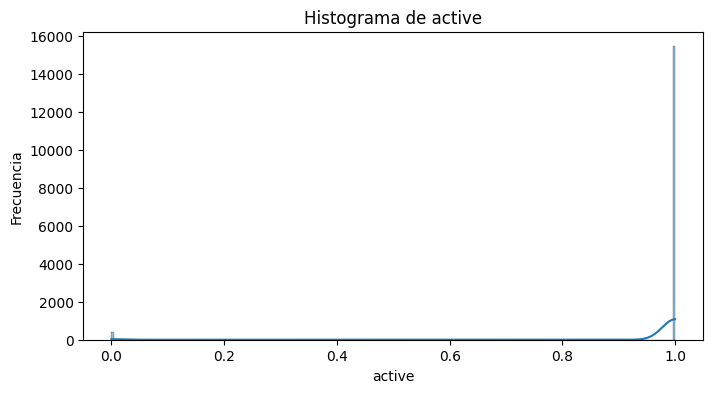

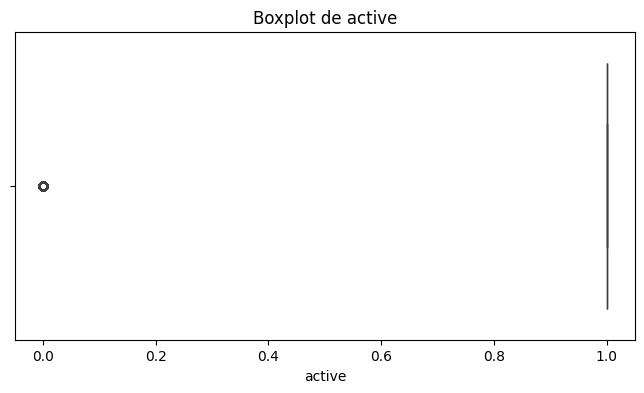

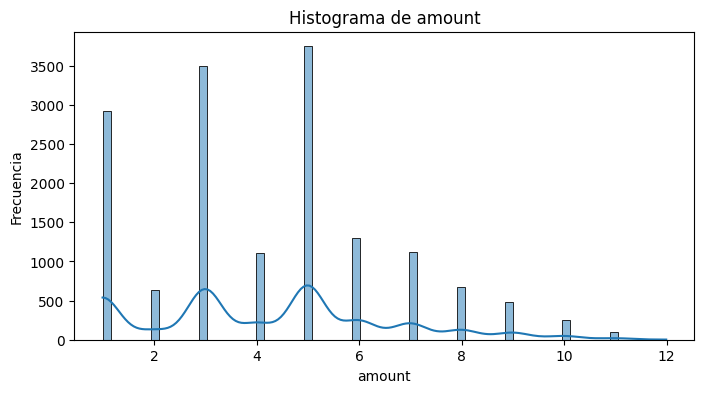

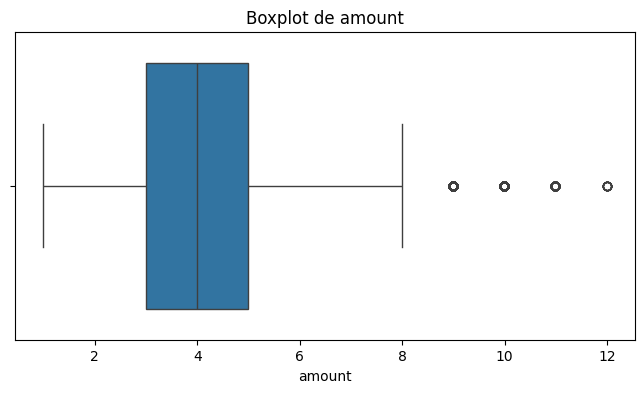

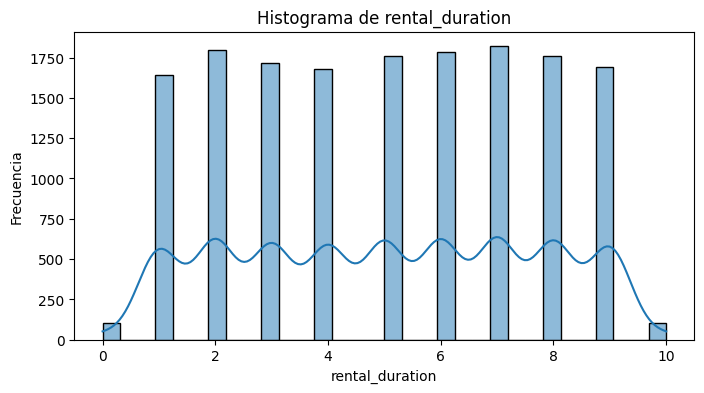

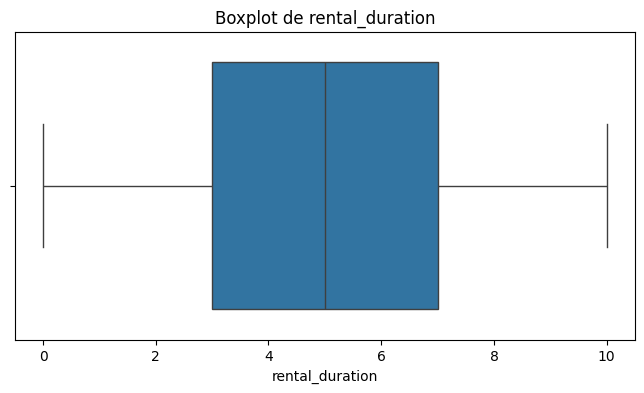

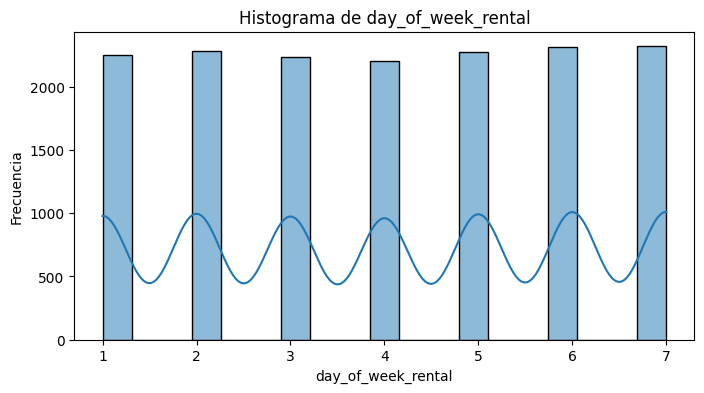

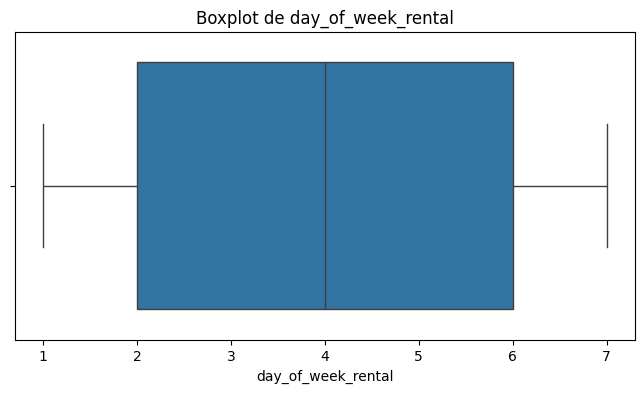

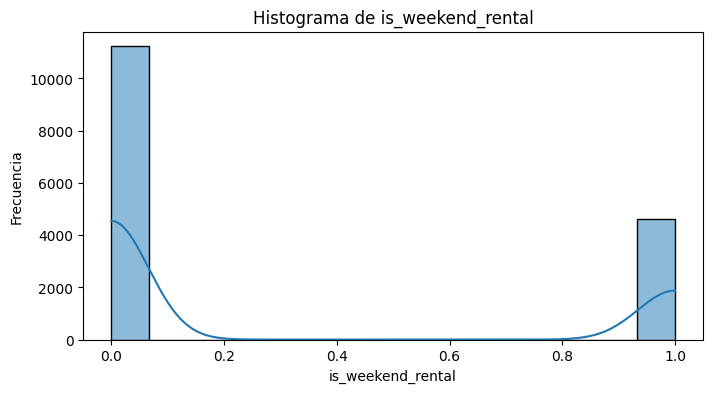

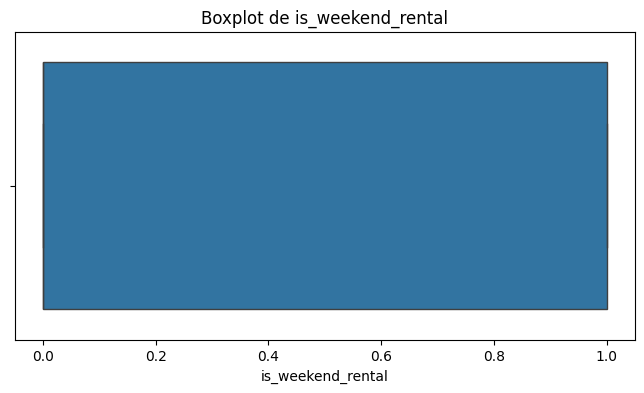

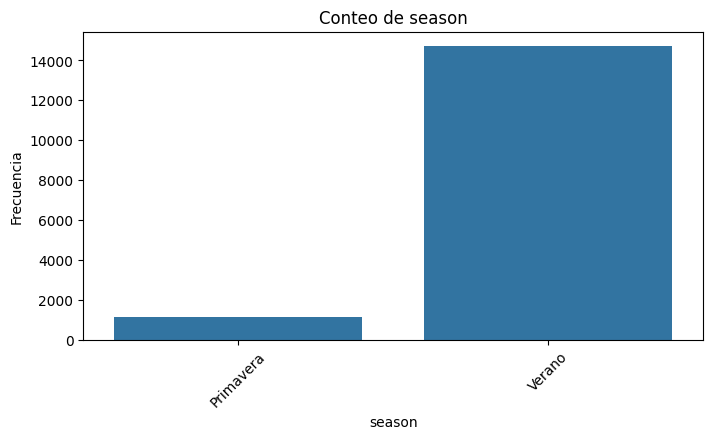

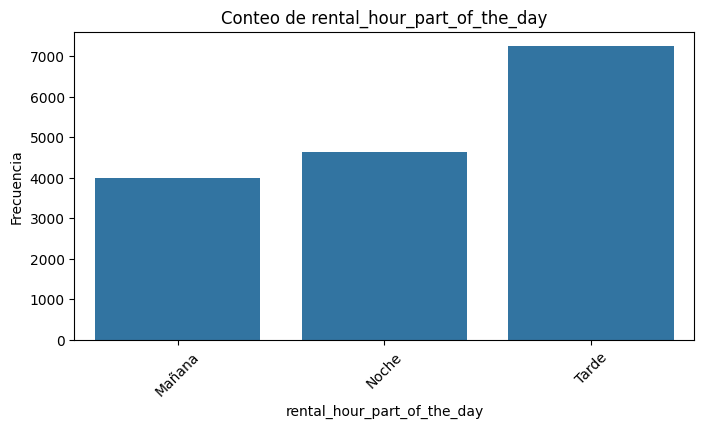

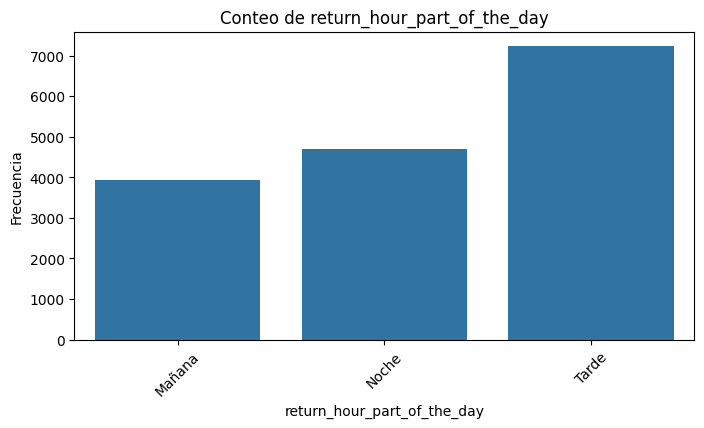

In [49]:
identify_outliers(df_clean, variables_numericas, variables_categoricas)

En este caso, solamente poseemos valores outliers en la columna amount, pero al tratarse de solamente 4 valores hemos decidido no realizar ningún tratamiento.

## Dashboard

### Alquileres por día y temporada

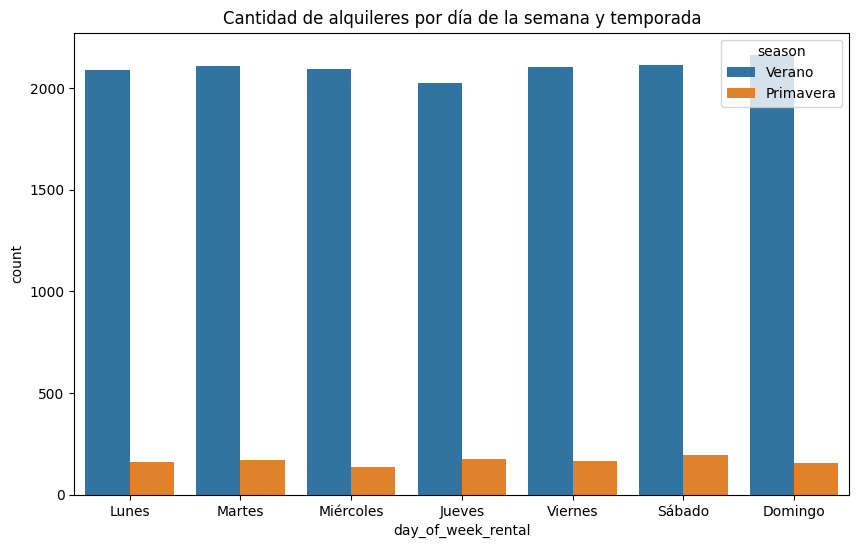

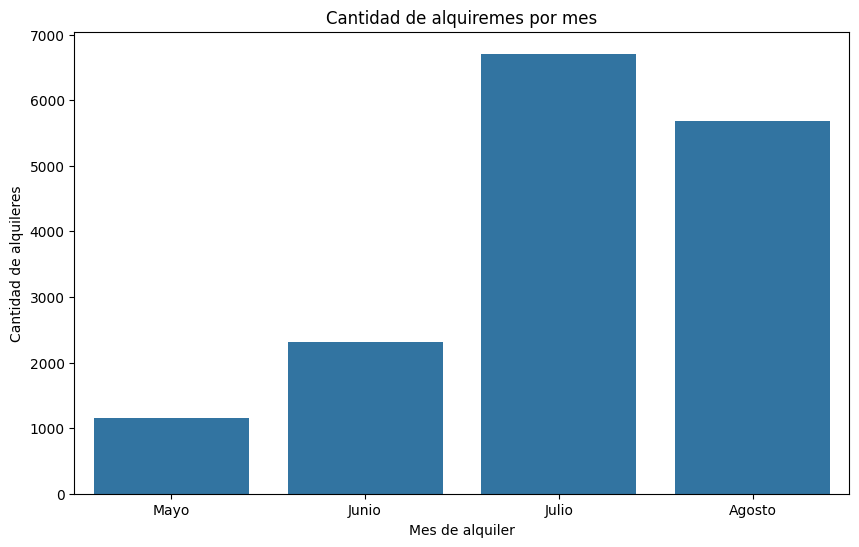

In [50]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_clean, x='day_of_week_rental', hue='season')
plt.xticks(ticks=[0, 1, 2, 3, 4, 5, 6], labels=['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo'])
plt.title('Cantidad de alquileres por día de la semana y temporada')
plt.show()
plt.figure(figsize=(10, 6))
sns.countplot(data=df_clean, x='rental_month')
plt.xticks(ticks=[0, 1, 2, 3], labels=['Mayo', 'Junio', 'Julio', 'Agosto'])
plt.xlabel('Mes de alquiler')
plt.ylabel('Cantidad de alquileres')
plt.title(f'Cantidad de alquiremes por mes')
plt.show()

### Histograma por año

In [51]:
df_filtrado = df_clean[df_clean['rental_year'] != 2005]
conteo = len(df_filtrado)
print(conteo)

0


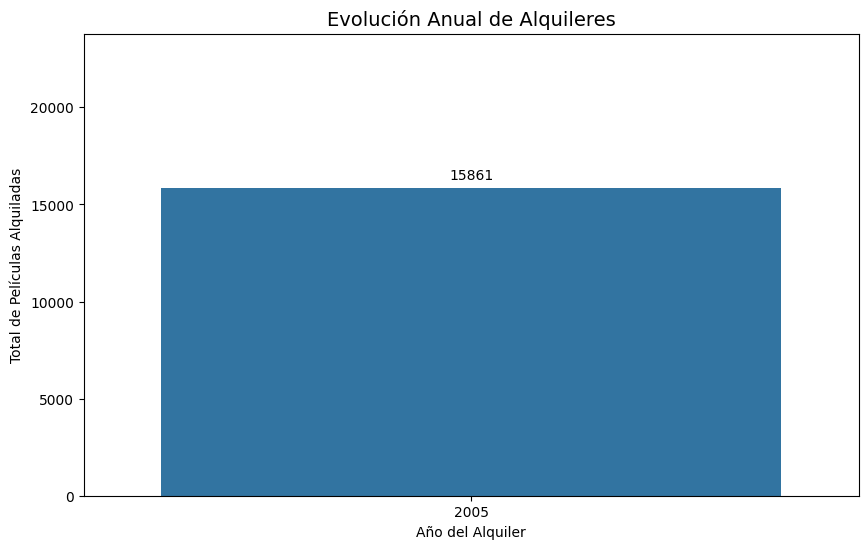

In [52]:
plt.figure(figsize=(10, 6))

# Usamos el año de alquiler en el eje X
sns.countplot(data=df_clean, x='rental_year')

# Añadimos etiquetas 
plt.title('Evolución Anual de Alquileres', fontsize=14)
plt.xlabel('Año del Alquiler')
plt.ylabel('Total de Películas Alquiladas')

# Añadimos el número exacto encima de cada barra para mayor claridad
ax = plt.gca()

max_height = df_clean['rental_year'].value_counts().max()
ax.set_ylim(0, max_height * 1.5)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')

plt.show()


### Histograma por horas del día 

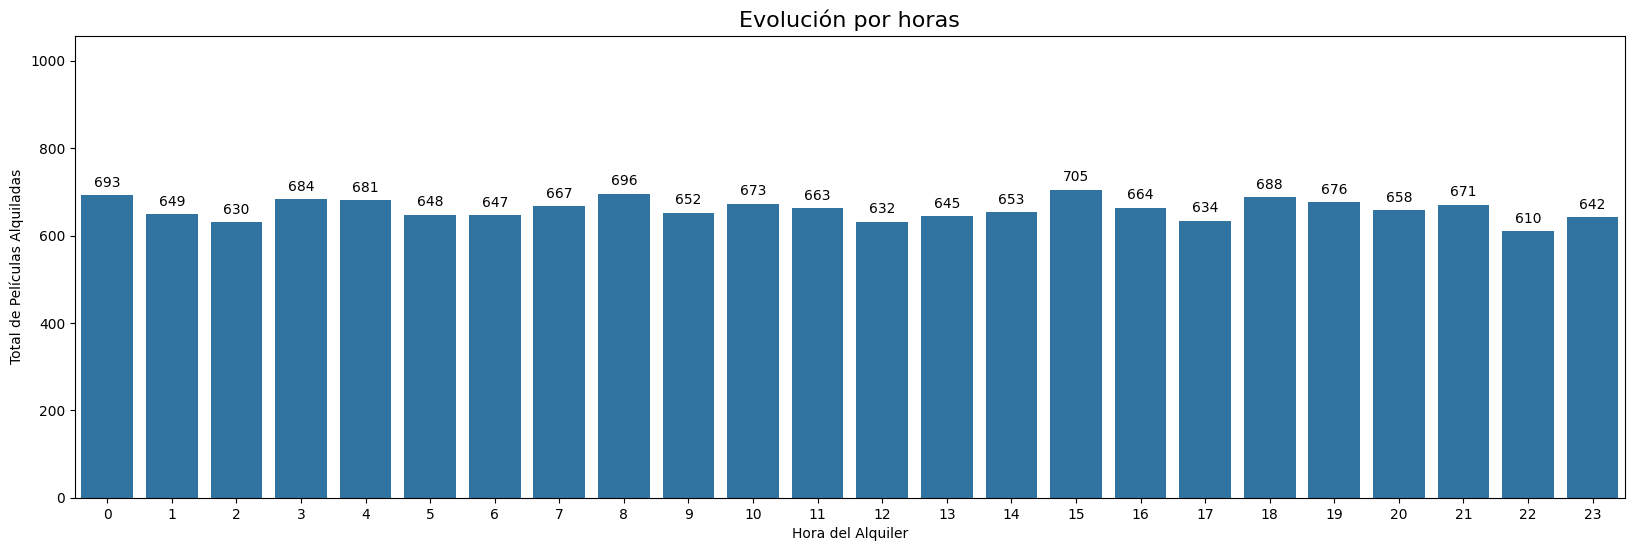

In [53]:
plt.figure(figsize=(20, 6))

# Usamos la hora de alquiler en el eje X
sns.countplot(data=df_clean, x='rental_hour')

# Añadimos etiquetas 
plt.title('Evolución por horas', fontsize=16)
plt.xlabel('Hora del Alquiler')
plt.ylabel('Total de Películas Alquiladas')

# Modificar la altura de y para que quede mas estético
ax = plt.gca()
max_height = df_clean['rental_hour'].value_counts().max()
ax.set_ylim(0, max_height * 1.5)

# Añadimos el número exacto encima de cada barra para mayor claridad

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')
    
plt.show()

### Usuarios que mas alquilan

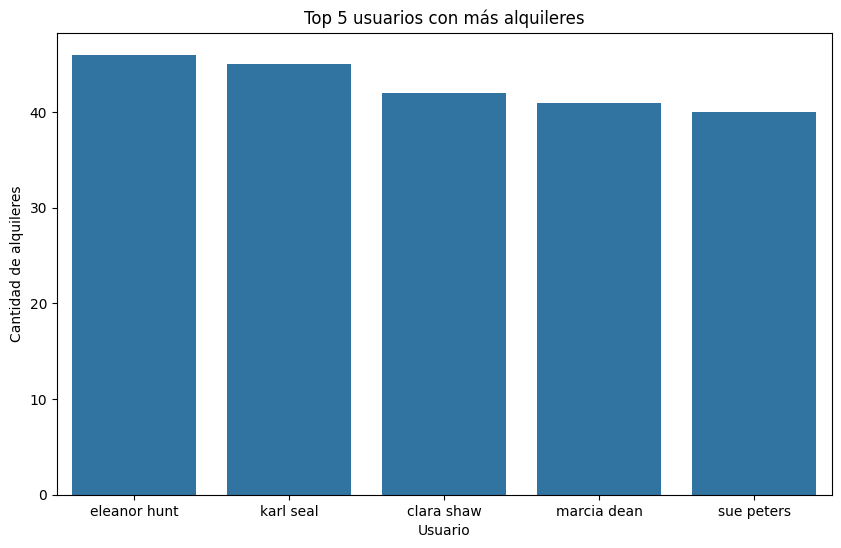

In [54]:
df_top_5_user = df_clean['full_name'].value_counts().head(5)

plt.figure(figsize=(10, 6))
sns.barplot(x=df_top_5_user.index, y=df_top_5_user.values)
plt.xlabel('Usuario')
plt.ylabel('Cantidad de alquileres')
plt.title('Top 5 usuarios con más alquileres')
plt.show()

## Exportación de datos procesados a CSV

In [55]:
load_clean_data(df_clean, '../output/client-activity-clean.csv')